# Potential Talent

## Data analysis

In [30]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from transformers import BertTokenizer, BertModel
from gensim.models import KeyedVectors
from sklearn.metrics.pairwise import cosine_similarity
from lightgbm import LGBMRanker
import numpy as np

In [31]:
df = pd.read_csv('data/PotentialTalentsData.csv') 
print(df.head())
print(df.info())
print(df.describe())

   id                                          job_title  \
0   1  2019 C.T. Bauer College of Business Graduate (...   
1   2  Native English Teacher at EPIK (English Progra...   
2   3              Aspiring Human Resources Professional   
3   4             People Development Coordinator at Ryan   
4   5    Advisory Board Member at Celal Bayar University   

                              location connection  fit  
0                       Houston, Texas         85  NaN  
1                               Kanada      500+   NaN  
2  Raleigh-Durham, North Carolina Area         44  NaN  
3                        Denton, Texas      500+   NaN  
4                       İzmir, Türkiye      500+   NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          104 non-null    int64  
 1   job_title   104 non-null    object 
 2   location    104 non-null

### Job title lenght histograms

<Axes: >

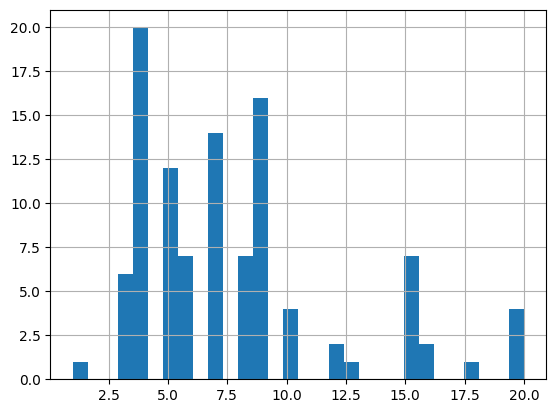

In [32]:
df['job_title_length'] = df['job_title'].apply(lambda x: len(str(x).split()))
df['job_title_length'].hist(bins=30)

### Top 20 Job Titles/keywords

In [33]:
from collections import Counter
words = " ".join(df['job_title']).lower().split()
common_words = Counter(words).most_common(20)
print(common_words)

[('human', 63), ('resources', 58), ('at', 46), ('aspiring', 35), ('and', 28), ('|', 28), ('professional', 20), ('student', 16), ('seeking', 15), ('college', 14), ('generalist', 14), ('university', 12), ('specialist', 12), ('of', 11), ('business', 11), ('in', 10), ('coordinator', 10), ('2019', 7), ('c.t.', 7), ('bauer', 7)]


### Connections' analysis

<Axes: >

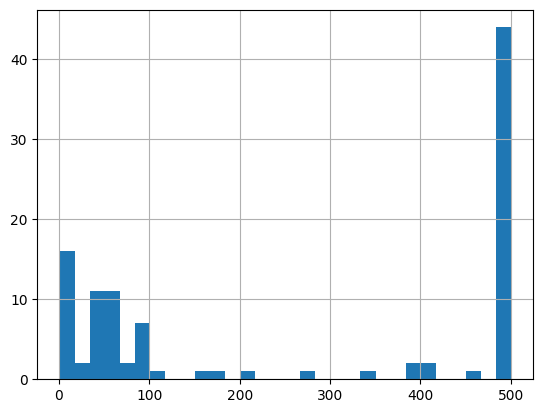

In [34]:
def process_connections(x):
    if isinstance(x, str) and "500" in x:
        return 500
    try:
        return int(x)
    except:
        return None

df['connections_numeric'] = df['connection'].apply(process_connections)
df['connections_numeric'].hist(bins=30)

### Missing Values check

In [35]:
print(df.isnull().sum())

id                       0
job_title                0
location                 0
connection               0
fit                    104
job_title_length         0
connections_numeric      0
dtype: int64


No missing value

## Data pre-processing

### Normalized connections function

In [36]:
def clean_connections(val):
    if isinstance(val, str) and "500" in val:
        return 500
    try:
        return int(val)
    except:
        return 0  # default if malformed


### Job title pre-processing

In [37]:
def clean_job_title(title):
    if pd.isna(title):
        return ""
    title = title.lower()                 # convert to lowercase
    title = title.strip()                # remove leading/trailing whitespace
    title = " ".join(title.split())      # remove extra internal spaces
    return title

df["job_title_clean"] = df["job_title"].apply(clean_job_title)

## Sentence-Bert Model

In [38]:
model = SentenceTransformer('all-MiniLM-L6-v2')  # small, fast, effective
embeddings = model.encode(df["job_title_clean"].tolist(), show_progress_bar=True)

Batches: 100%|██████████| 4/4 [00:01<00:00,  2.13it/s]


### Testing before adding weightage of connections

In [39]:
test_keyword = "aspiring human resources"
keyword_embedding = model.encode([test_keyword])[0]  # shape: (384,)

In [40]:
# Reshape keyword embedding for comparison
keyword_embedding = keyword_embedding.reshape(1, -1)

# Compute cosine similarity between keyword and each job title
similarities = cosine_similarity(embeddings, keyword_embedding).flatten()

# Add similarity scores to DataFrame
df["fit_score"] = similarities

In [41]:
# Sort candidates by fit_score (highest similarity to keyword)
top_matches = df.sort_values("fit_score", ascending=False)

# View top 5 candidates
print(top_matches[["job_title", "fit_score"]].head(20))

                                            job_title  fit_score
96              Aspiring Human Resources Professional   0.949807
2               Aspiring Human Resources Professional   0.949807
45              Aspiring Human Resources Professional   0.949807
20              Aspiring Human Resources Professional   0.949807
16              Aspiring Human Resources Professional   0.949807
32              Aspiring Human Resources Professional   0.949807
57              Aspiring Human Resources Professional   0.949807
23                Aspiring Human Resources Specialist   0.928035
35                Aspiring Human Resources Specialist   0.928035
48                Aspiring Human Resources Specialist   0.928035
59                Aspiring Human Resources Specialist   0.928035
5                 Aspiring Human Resources Specialist   0.928035
98                   Seeking Human Resources Position   0.808784
29              Seeking Human Resources Opportunities   0.799642
27              Seeking H

### Cleaning, Normalizing and scaling connections' values

In [42]:
df["connections_clean"] = df["connection"].apply(clean_connections)

# Normalize to range [0, 1]
df["connections_norm"] = df["connections_clean"] / 500

### Adding connections weightage by 10%

In [43]:
df["final_score"] = 0.9 * df["fit_score"] + 0.1 * df["connections_norm"]

In [44]:
top_candidates = df.sort_values("final_score", ascending=False)

# View top results
print(top_candidates[["job_title", "fit_score", "connections_clean", "final_score"]].head(20))

                                            job_title  fit_score  \
96              Aspiring Human Resources Professional   0.949807   
2               Aspiring Human Resources Professional   0.949807   
57              Aspiring Human Resources Professional   0.949807   
45              Aspiring Human Resources Professional   0.949807   
20              Aspiring Human Resources Professional   0.949807   
16              Aspiring Human Resources Professional   0.949807   
32              Aspiring Human Resources Professional   0.949807   
23                Aspiring Human Resources Specialist   0.928035   
59                Aspiring Human Resources Specialist   0.928035   
5                 Aspiring Human Resources Specialist   0.928035   
48                Aspiring Human Resources Specialist   0.928035   
35                Aspiring Human Resources Specialist   0.928035   
29              Seeking Human Resources Opportunities   0.799642   
27              Seeking Human Resources Opportun

## Word2Vec Model

In [ ]:
# Load pretrained Google News vectors
# NOTE: Word2Vec model data file "GoogleNews-vectors-negative300.bin" is availabe at kaggle.
w2v_model = KeyedVectors.load_word2vec_format("GoogleNews-vectors-negative300.bin", binary=True)

#### Get average Word2Vec Vector

In [46]:
def get_avg_w2v_vector(text, model):
    words = text.lower().split()
    valid_vectors = [model[word] for word in words if word in model]
    if valid_vectors:
        return np.mean(valid_vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

#### Embedding job_titles to Word2Vec

In [47]:
# Embed job titles
df["job_title_vec"] = df["job_title"].apply(lambda x: get_avg_w2v_vector(x, w2v_model))

#### Testing a keyword

In [48]:
# Keyword
keyword = "aspiring human resources"
keyword_vec = get_avg_w2v_vector(keyword, w2v_model)

#### Calculating cosine similarity between keyword and Job title Embeddings

In [49]:
# Compute cosine similarity between each job title and the keyword
df["similarity"] = df["job_title_vec"].apply(lambda vec: cosine_similarity([vec], [keyword_vec])[0][0])

In [50]:
ranked = df.sort_values(by="similarity", ascending=False)[["id", "job_title", "similarity"]].head(20)
print(ranked)

     id                                          job_title  similarity
45   46              Aspiring Human Resources Professional    0.945019
96   97              Aspiring Human Resources Professional    0.945019
32   33              Aspiring Human Resources Professional    0.945019
20   21              Aspiring Human Resources Professional    0.945019
57   58              Aspiring Human Resources Professional    0.945019
16   17              Aspiring Human Resources Professional    0.945019
2     3              Aspiring Human Resources Professional    0.945019
23   24                Aspiring Human Resources Specialist    0.905420
5     6                Aspiring Human Resources Specialist    0.905420
48   49                Aspiring Human Resources Specialist    0.905420
35   36                Aspiring Human Resources Specialist    0.905420
59   60                Aspiring Human Resources Specialist    0.905420
73   74                       Human Resources Professional    0.865165
72   7

### Adding 10% weightage of connections feature to Word2Vec Embeddings.

In [51]:
df["final_similarity"] = 0.9 * df["similarity"] + 0.1 * df["connections_norm"]

In [52]:
Reranked = df.sort_values(by="final_similarity", ascending=False)[["id", "job_title", "similarity", "final_similarity"]].head(20)
print(Reranked)

      id                                          job_title  similarity  \
96    97              Aspiring Human Resources Professional    0.945019   
57    58              Aspiring Human Resources Professional    0.945019   
2      3              Aspiring Human Resources Professional    0.945019   
20    21              Aspiring Human Resources Professional    0.945019   
45    46              Aspiring Human Resources Professional    0.945019   
16    17              Aspiring Human Resources Professional    0.945019   
32    33              Aspiring Human Resources Professional    0.945019   
23    24                Aspiring Human Resources Specialist    0.905420   
59    60                Aspiring Human Resources Specialist    0.905420   
48    49                Aspiring Human Resources Specialist    0.905420   
35    36                Aspiring Human Resources Specialist    0.905420   
5      6                Aspiring Human Resources Specialist    0.905420   
28    29  Aspiring Human 

Both NLP models worked very well. But by comparing the result of both Sentence-Bert and Word2Vec, it can be clearly seen that sentence-Bert worked better than Word2Vec. Sentence-Bert brought better results.

### Preference to starred candidate.

LightGBMRanker will be used to rank the candidates. <br><br>
As Sentence-Bert worked better than Word2Vec. So the embedded vectors from Sentence-Bert will be used to feed LightGBMRanker. 

Suppose 13th candidate (with id = 99) has been starred from the top fit candidates of Sentence-Bert embedding similar to "aspiring human resources" keyword.

In [60]:
# creating a new column named as relevance. This column will contain 1 against starred candidate/result.
# Rest of the other candidates will get zero. This relevance column will be used as target/y in LightGBMRanker.
starred_id = 99
df["relevance"] = df["id"].apply(lambda x: 1 if x == starred_id else 0)

In [61]:
# fit_score and connections have been used separately.
# To feed to LightGBMRanker it is not necessary to lower the weightage of connections.
# LightGBMRanker is smart enough, it realizes if some feature is not imposing a big impact. 
# Then it automatically lower the weightage of that feature.
X = df[["fit_score", "connections_norm"]] 
y = df["relevance"]

In [62]:
# LightGBM expects group sizes per query — here we assume one query group (keyword)
group = [len(df)]
ranker = LGBMRanker(objective="lambdarank", metric="ndcg", n_estimators=50)
ranker.fit(X, y, group=group)

LGBMRanker(metric='ndcg', n_estimators=50, objective='lambdarank')

In [63]:
df["lgbm_score"] = ranker.predict(X)
df_sorted = df.sort_values("lgbm_score", ascending=False)

print(df_sorted[["id", "job_title", "connection", "fit_score", "relevance", "lgbm_score"]].head(20))

      id                                          job_title connection  \
98    99                   Seeking Human Resources Position         48   
29    30              Seeking Human Resources Opportunities        390   
27    28              Seeking Human Resources Opportunities        390   
83    84  Human Resources professional for the world lea...         50   
101  102   Business Intelligence and Analytics at Travelers         49   
45    46              Aspiring Human Resources Professional         44   
35    36                Aspiring Human Resources Specialist          1   
48    49                Aspiring Human Resources Specialist          1   
32    33              Aspiring Human Resources Professional         44   
23    24                Aspiring Human Resources Specialist          1   
20    21              Aspiring Human Resources Professional         44   
16    17              Aspiring Human Resources Professional         44   
59    60                Aspiring Human

It could be seen that starred candidate moved from 13th position to top position for the keyword "aspiring human resources". Even the candidates at 2nd, 3rd, and 4th are more similar to starred one with respect to keyword.